# Investigate homologous recombinations
- do they usually span a whole junctions
- how are the SNPs distributed over the core blocks
- how many recombination events do we find distributed over the whole genome
- ...

In [6]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

from sklearn.metrics import adjusted_mutual_info_score
import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, summarize_clustering_thresholds, compute_within_between_cluster_distances, add_silhouette_scores
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_snp_position_cdfs, plot_snp_gap_histogram
from junction_analysis.plotting import plot_all_junctions_pairwise_distances, plot_junction_heatmap, plot_clustering_threshold_sweep, plot_all_junctions_pairwise_distances_zoom, plot_score_threshold_violin, plot_core_alignment_lengths, plot_ambiguous_block_distances
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events

In [2]:
# alternatively read presaved results
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

## Junctions with more than 2 core blocks

What I found out about junction pangraphs:
- core definition is decided from first pangraph run (not rerun based on junctions), that's why rarely blocks can be present in all isolates but not core if a junction doesnt contain all isolates
- some junctions have more than 2 flanking core blocks (some have 3, 4, 5, or 6 and some have only 1, always at least 1)
- core blocks are never inverted, I think

In [ ]:
for junction_id in jdf["edge"].tolist():
    pangraph = pp.Pangraph.from_json(f"../results/junction_pangraphs/{junction_id}.json")
    bs_df = pangraph.to_blockstats_df()
    n_core = len(bs_df[bs_df['core'] == True])
    if n_core != 2:
        print(junction_id, n_core)

# 114 junctions have not exactly 2 core blocks (some have 3, 4, 5, or 6 and some have only 1, always at least 1)

## Distribution of SNPs

In [5]:
#snp_pos_df = core_block_snp_gaps('../results', save_path="../results/consensus_analysis/core_block_snp_pos.csv")
snp_pos_df = pd.read_csv("../results/consensus_analysis/core_block_snp_pos.csv")
snp_pos_df.head()

,junction_name,block_id,aln_length,snp_positions,gap_lengths
0,ADIVNXMSJF_f__SKCSCYCISB_f,10026712397854510732,8824,"[93, 708, 2444, 2451, 3072, 3376, 3546, 3796, ...","[93, 615, 1736, 7, 621, 304, 170, 250, 55, 120..."
1,ADIVNXMSJF_r__CGRLRHSCCE_f,12675429639006275041,4283,"[417, 472, 722, 892, 1196, 1817, 1824, 3560, 4...","[417, 55, 250, 170, 304, 621, 7, 1736, 615, 107]"
2,ADIVNXMSJF_r__CGRLRHSCCE_f,12918894780908767512,1440,"[553, 884, 1212, 1282]","[553, 331, 328, 70, 157]"
3,ADOVFNSINA_f__ECOWCWQMQJ_f,12863862502596669040,7190,"[700, 1059, 1148, 2489, 2537, 3376, 4056, 4655...","[700, 359, 89, 1341, 48, 839, 680, 599, 271, 3..."
4,ADOVFNSINA_f__ECOWCWQMQJ_f,17002209191645103675,1295,"[245, 482, 779]","[245, 237, 297, 515]"


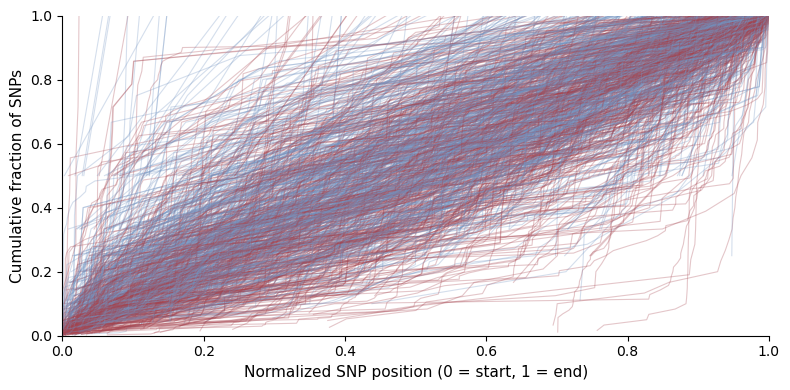

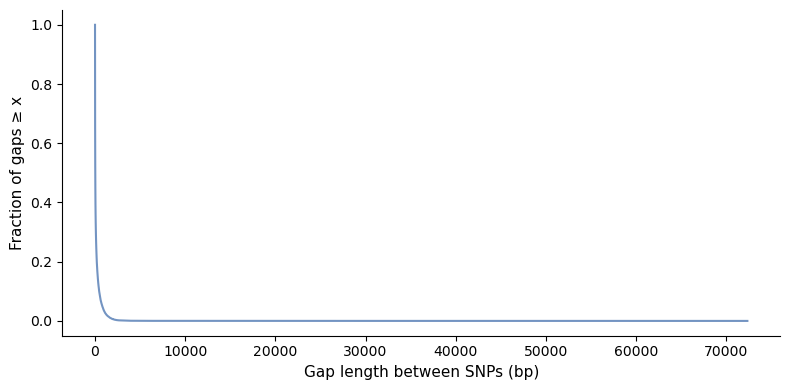

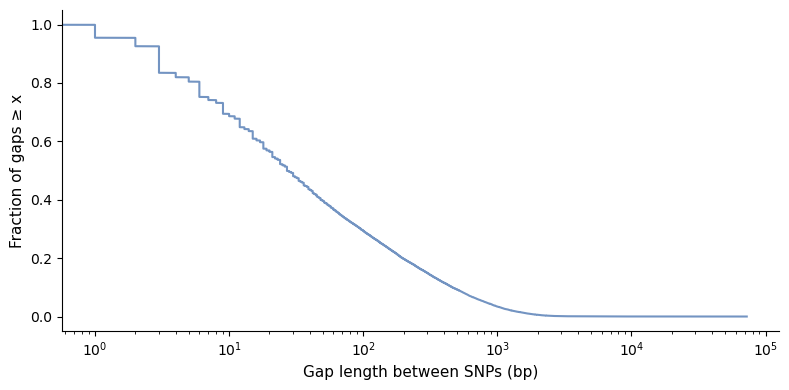

In [8]:
plot_snp_position_cdfs(snp_pos_df, figsize=(8, 4), alpha=0.3, highlight_junctions=jdf_all[jdf_all['n_clusters'] > 1].junction_name.to_list())
#plot_snp_gap_histogram(snp_pos_df, bins=100, log_y=False, figsize=(8, 4))
plot_snp_gap_histogram(snp_pos_df, bins=100, log_y=False, figsize=(8, 4), cumulative=True)
plot_snp_gap_histogram(snp_pos_df, bins=100, log_y=False, figsize=(8, 4), cumulative=True, log_x = True)